In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from google.colab import files


uploaded = files.upload()

Saving nigeria_houses_data.csv to nigeria_houses_data.csv


In [3]:
print ('Dimensions of the dataset:')
df = pd.read_csv('nigeria_houses_data.csv')
df.shape


Dimensions of the dataset:


(24326, 8)

In [3]:
print ('Data types of each column:')
df.info()

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24326 entries, 0 to 24325
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   bedrooms       24326 non-null  int64  
 1   bathrooms      24326 non-null  int64  
 2   toilets        24326 non-null  int64  
 3   parking_space  24326 non-null  int64  
 4   title          24326 non-null  object 
 5   town           24326 non-null  object 
 6   state          24326 non-null  object 
 7   price          24326 non-null  float64
dtypes: float64(1), int64(4), object(3)
memory usage: 1.5+ MB


In [4]:
print ('Missing values:')
df.isnull().sum()



Missing values:


,0
bedrooms,0
bathrooms,0
toilets,0
parking_space,0
title,0
town,0
state,0
price,0


In [5]:
print ('Descriptive statistics')
print(df[['price', 'bedrooms', 'bathrooms']].describe())

Descriptive statistics
              price      bedrooms     bathrooms
count  2.432600e+04  24326.000000  24326.000000
mean   3.013802e+08      4.338814      4.600798
std    1.220403e+10      1.138497      1.163161
min    9.000000e+04      1.000000      1.000000
25%    5.200000e+07      4.000000      4.000000
50%    8.500000e+07      4.000000      5.000000
75%    1.600000e+08      5.000000      5.000000
max    1.800000e+12      9.000000      9.000000


Original Price Skewness: 135.02


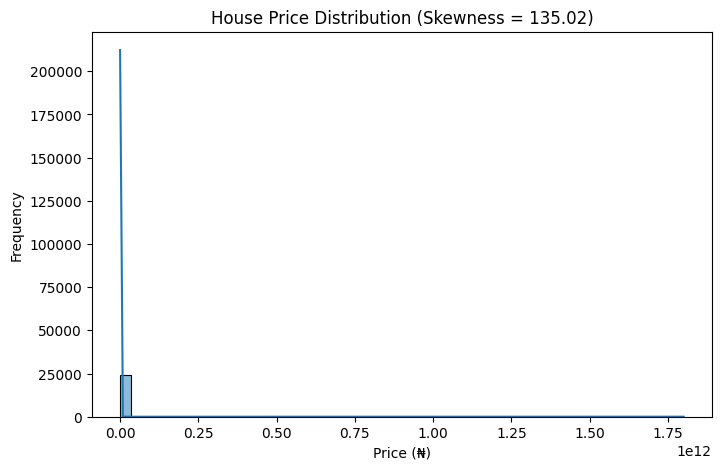

In [9]:
from scipy.stats import skew

prices = df['price'].dropna()

price_skewness = skew(prices)
print(f"Original Price Skewness: {price_skewness:.2f}")

plt.figure(figsize=(8,5))
sns.histplot(prices, bins=50, kde=True)
plt.title(f'House Price Distribution (Skewness = {price_skewness:.2f})')
plt.xlabel('Price (₦)')
plt.ylabel('Frequency')
plt.show()


Log-Transformed Price Skewness: 0.23


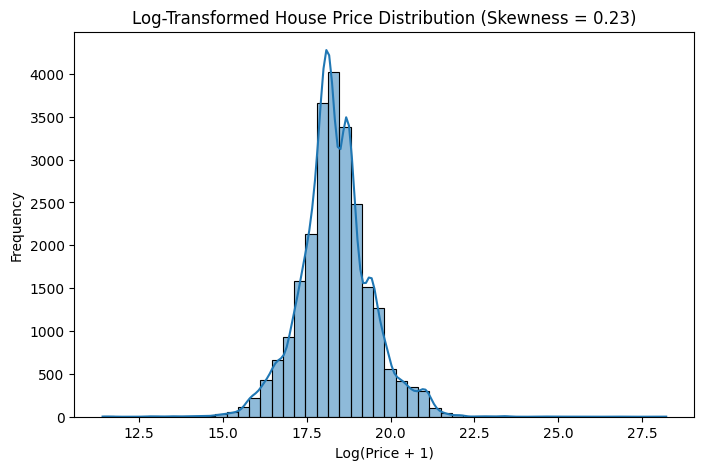

In [11]:
log_prices = np.log1p(prices)  # log1p handles zeros safely

# Calculate skewness (log-transformed)
log_price_skewness = skew(log_prices)
print(f"Log-Transformed Price Skewness: {log_price_skewness:.2f}")

# Plot log-transformed distribution
plt.figure(figsize=(8,5))
sns.histplot(log_prices, bins=50, kde=True)
plt.title(f'Log-Transformed House Price Distribution (Skewness = {log_price_skewness:.2f})')
plt.xlabel('Log(Price + 1)')
plt.ylabel('Frequency')
plt.show()

state
Lagos     18445
Abuja      3524
Ogun        637
Oyo         477
Rivers      444
Name: count, dtype: int64


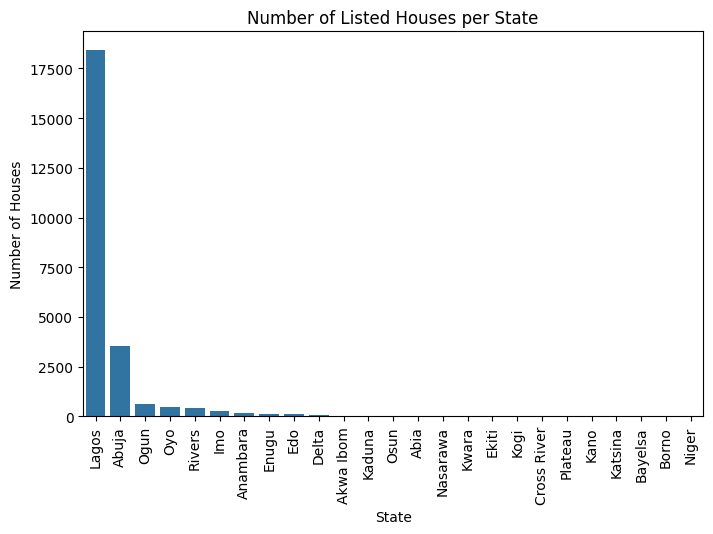

In [13]:
state_counts = df['state'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=state_counts.index, y=state_counts.values)
plt.title("Number of Listed Houses per State")
plt.xlabel("State")
plt.ylabel("Number of Houses")
plt.xticks(rotation=90)
plt.show()

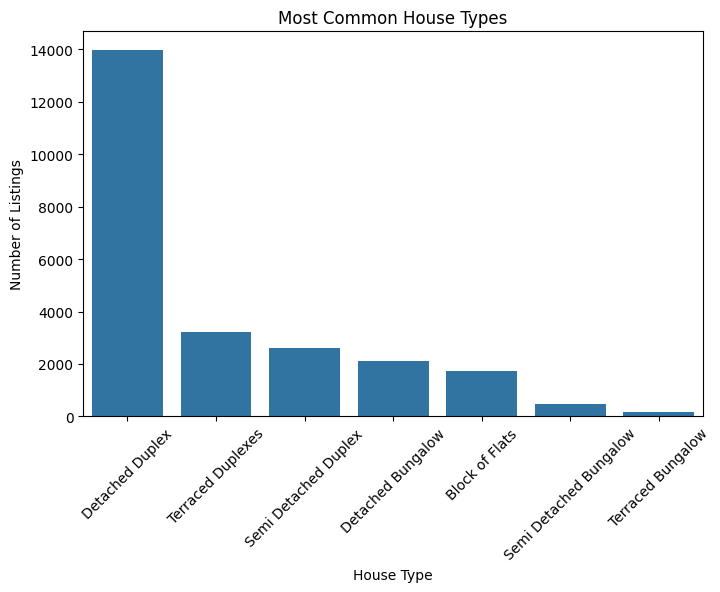

In [17]:
house_types = df['title'].value_counts()

# Plot bar chart
plt.figure(figsize=(8,5))
sns.barplot(x=house_types.index, y=house_types.values)
plt.title("Most Common House Types")
plt.xlabel("House Type")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.show()

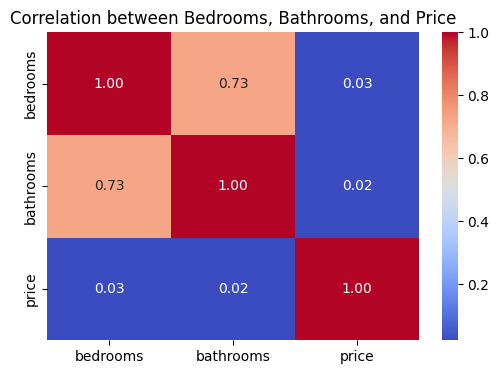

In [18]:
corr_data = df[['bedrooms', 'bathrooms', 'price']]

plt.figure(figsize=(6,4))
sns.heatmap(corr_data.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation between Bedrooms, Bathrooms, and Price")
plt.show()



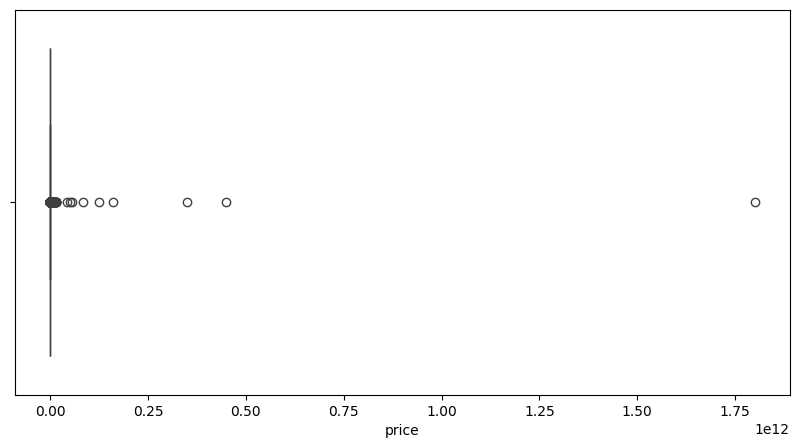

In [5]:


plt.figure(figsize=(10,5))
sns.boxplot(x=df['price'])
plt.show()

In [13]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
print("Number of price outliers:", len(outliers))

Number of price outliers: 2558


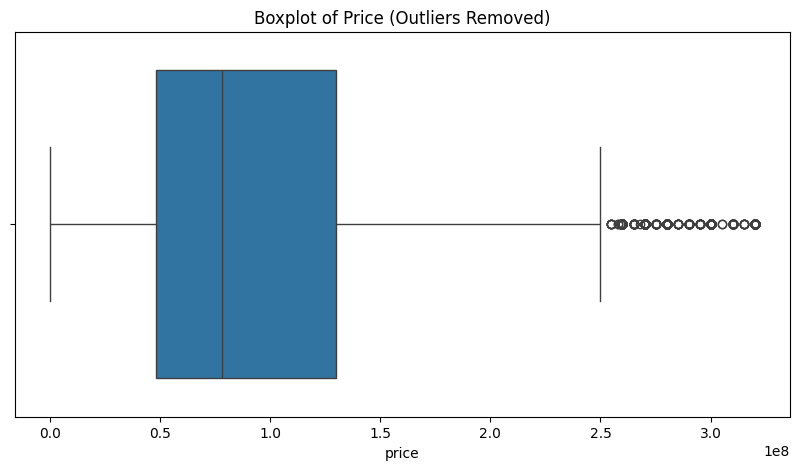

In [15]:
df_no_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
plt.figure(figsize=(10,5))
sns.boxplot(x=df_no_outliers['price'])
plt.title("Boxplot of Price (Outliers Removed)")
plt.show()

In [17]:

lagos_data = df[df['state'].str.lower() == "lagos"]

# Group by town and get the one with highest average price
top_town = lagos_data.groupby('town')['price'].mean().idxmax()

print("Town in Lagos with the highest average house price:", top_town)

Town in Lagos with the highest average house price: Ikoyi


In [19]:
# Group by parking_space and calculate mean price
parking_price_relation = df.groupby('parking_space')['price'].mean().sort_index()

print(parking_price_relation)

parking_space
1    2.976094e+08
2    1.008732e+08
3    1.150646e+08
4    2.618928e+08
5    2.035934e+08
6    2.344157e+08
7    2.589029e+08
8    2.700190e+09
9    2.117167e+08
Name: price, dtype: float64


In [21]:
# Group by house title and calculate median price
title_median_price = df.groupby('title')['price'].median().sort_values(ascending=False)


top_title = title_median_price.idxmax()
top_median_price = title_median_price.max()

print("House title with the highest median price:", top_title)
print("Median price:", top_median_price)

House title with the highest median price: Detached Duplex
Median price: 130000000.0


In [22]:
# To Create a new column: price per bedroom
df['price_per_bedroom'] = df['price'] / df['bedrooms']


state_value = df.groupby('state')['price_per_bedroom'].mean().sort_values()

# Get state with best value (lowest price per bedroom)
best_state = state_value.idxmin()
best_value = state_value.min()

print("State offering the best value for money:", best_state)
print("Average price per bedroom:", best_value)

State offering the best value for money: Plateau
Average price per bedroom: 2053571.4285714286
